# Marching Qubes Classical Vertex Classification V1
## Brandon Watanabe

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [25]:
"""
 Summary:
    Perform Marching Cubes vertex classification on a scalar field.
    Each vertex is classified according to a threshold isolevel:
        return 1    if input_val > isolevel
        return 0    otherwise

Parameters:
    input_val : int
        Intensity values in range [0, 255].

    isolevel : int
        Threshold value for classification.

Returns:
    int values in range [0, 1].
"""
def classify_vertex_classical(input_val, isolevel):
    return int(input_val > isolevel)

In [ ]:
"""
Summary:
    Create a dataset of 4 different 1D arrays.
    Arrays will be 16 values in length in varying patterns:
        - 8x 00s / 8x FFs
        - 4x 00s / 4x FFs / 4x 00s / 4x FFs
        - 2x... 2x...
        - Alternating 00 FF 00 FF...

Parameters:
    None

Returns:
    Dictionary of 1D numpy arrays containing 16 8-bit values
"""
def construct_1D_datasets():
    datasets = {}

    # 8x 00 / 8x FFs
    datasets["8-block"] = np.array([0]*8 + [255]*8)

    # 4x 00s / 4x FFs / 4x 00s / 4x FFs
    datasets["4-block"] = np.array([0]*4 + [255]*4 + [0]*4 + [255]*4)

    # 2x... 2x...
    datasets["2-block"] = np.tile([0,0,255,255], 4)

    # Alternating 00 FF 00 FF...
    datasets["1-block"] = np.tile([0,255], 8)

    return datasets

In [8]:
"""
Summary:
    Create a dataset of 4 different 2D arrays.
    Arrays will be 16x16 values in length in varying patterns:
        - half/half vertically
        - half/half horizontally
        - quarter/quarter 
        - checkerboard

Parameters:
    None

Returns:
    Dictionary of 2D numpy arrays containing 16x16 8-bit values
"""
def construct_2D_datasets(size=16):
    half = size // 2
    
    datasets = {}

    # Vertical half/half
    vertical = np.zeros((size, size), dtype=np.uint8)
    vertical[:, half:] = 255
    datasets["vertical_h/h"] = vertical

    # Horizontal half/half
    horizontal = np.zeros((size, size), dtype=np.uint8)
    horizontal[half:, :] = 255
    datasets["horizontal_h/h"] = horizontal

    # Quarter / Quarter 
    quadrant = np.zeros((size, size), dtype=np.uint8)
    quadrant[:half, half:] = 255
    quadrant[half:, :half] = 255
    datasets["quadrant_split"] = quadrant

    # Checkerboard 
    checkerboard = (np.indices((size, size)).sum(axis=0) % 2) * 255
    datasets["checkerboard"] = checkerboard.astype(np.uint8)

    return datasets

In [21]:
def visualize_classification_1D(inputs, outputs):
    for name in inputs.keys():

        fig, ax = plt.subplots(1, 2, figsize=(8, 1))

        ax[0].imshow(inputs[name].reshape(1, -1), cmap='gray', aspect='auto')
        ax[0].set_title(f"{name} - Input")

        ax[1].imshow(outputs[name].reshape(1, -1), cmap='hot', aspect='auto')
        ax[1].set_title("Classified")
        
        fig.colorbar(ax[1].images[0], ax=ax[1])

        plt.show()

def visualize_classification_2D(inputs, outputs):
    for name in inputs.keys():
        fig, ax = plt.subplots(1, 2, figsize=(8, 4))

        ax[0].imshow(inputs[name], cmap='gray')
        ax[0].set_title(f"{name} - Input")

        ax[1].imshow(outputs[name], cmap='hot')
        ax[1].set_title("Classified")
        
        fig.colorbar(ax[1].images[0], ax=ax[1])

        plt.show()

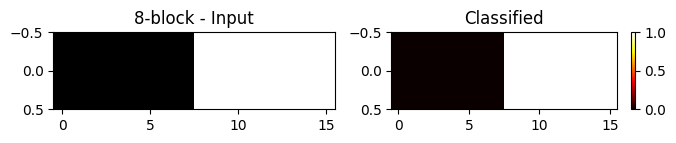

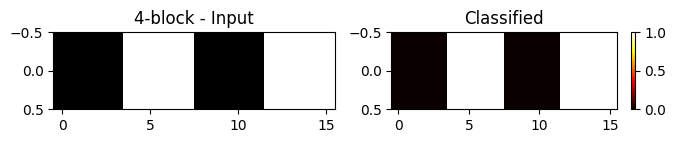

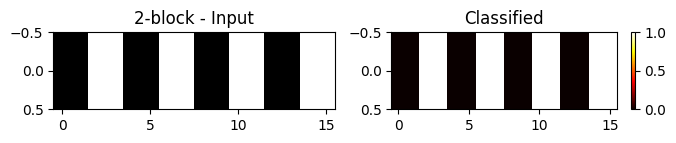

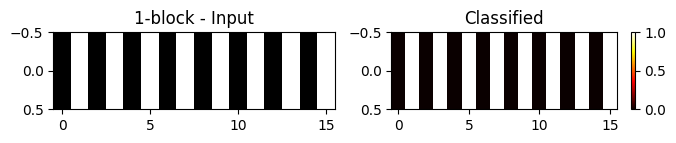

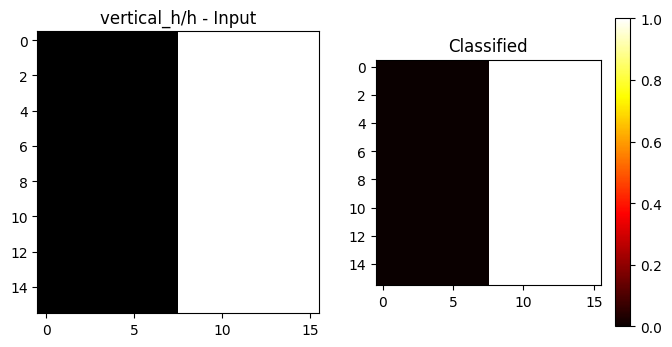

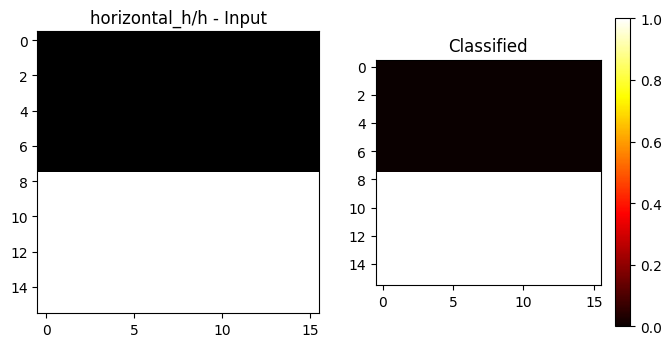

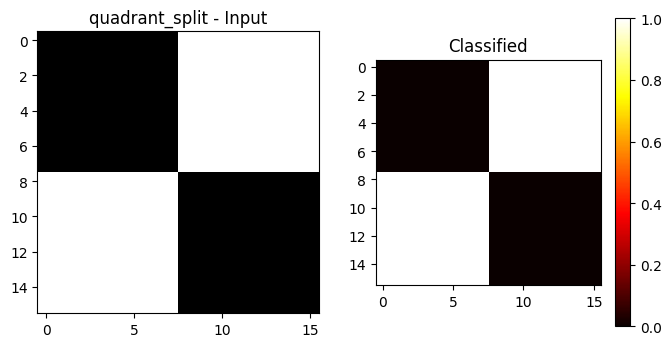

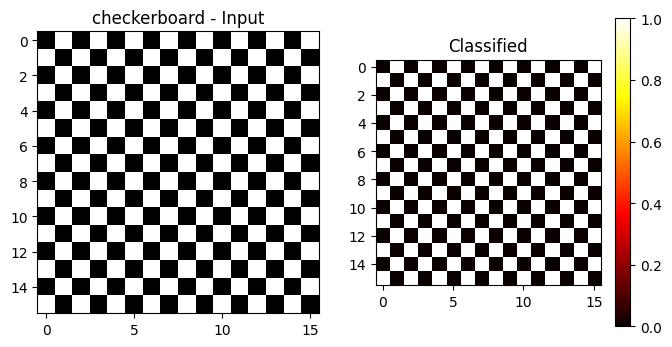

In [26]:
isolevel = 128

# 1D
datasets_1D = construct_1D_datasets()
outputs_1D = {}

for name, data in datasets_1D.items():
    outputs_1D[name] = (data > isolevel).astype(int)

visualize_classification_1D(datasets_1D, outputs_1D)


# 2D
datasets_2D = construct_2D_datasets()
outputs_2D = {}

for name, data in datasets_2D.items():
    outputs_2D[name] = (data > isolevel).astype(int)

visualize_classification_2D(datasets_2D, outputs_2D)

In [ ]:
# EOF

In [6]:
T = [0.9, 0.51, 0.5, 0, -0.5, -0.9]

for t in T:
    w = t / (1 - t)
    print(f"t: {t}, w: {w}")

    a = np.arccos(1 - 2 * w)
    print(f"a: {a}")


t: 0.9, w: 9.000000000000002
a: nan
t: 0.51, w: 1.0408163265306123
a: nan
t: 0.5, w: 1.0
a: 3.141592653589793
t: 0, w: 0.0
a: 0.0
t: -0.5, w: -0.3333333333333333
a: nan
t: -0.9, w: -0.4736842105263158
a: nan


C:\Users\burne\AppData\Local\Temp\ipykernel_996\3263404739.py:7: RuntimeWarning: invalid value encountered in arccos
  a = np.arccos(1 - 2 * w)
